<a href="https://colab.research.google.com/github/salnagisa0120/DeepLearning/blob/main/Salosa_Amri_Pamungkas_Deep_Learning_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning_Salosa Amri Pamungkas

<div class="markdown-google-sans">

## Exploratory Data Analysis
</div>

Element of Structured Data, Data comes from many sources: sensor measurements, events, text, image, and videos. the IoT is spewing out streams of informasion. Musch of this data is unstructured: images are a collection of pixels, with each pixel containing RGB color information.

Texts are sequences of words and nonword characters, often organized by sections, subsections, and so on.

Key of Terms for Data Types

Numeric, data that are expressed on a numeric scale
  Continuous, Data that can take on any value in an interval.
  Discrete, Data that can take on only integer values such a counts.

Categorical, Data that can take on only a specific set of values representng a set of possible categories.
  Binary, a specal case of categoriical data wth just two categories of values. e.g., 0/1, True/False.
  Ordinal, categorical data that has an explict ordering.

Software engneers and database programmers may wonder why we even need the motiion of categorical and ordinal data for analytics. After all, categories are merely a collection of text (or numeric) values, and the underlyng database automatically handles the internal representation.

Key Ideas
  - Data is typically classifed in software by type.
  - Data types inlcude numerc and categorical.
  - Data typng in software acts as a sgnal to the software on how to process the data


Rectangular Data
  The typical frame of reference for an analysis iiin data science is a rectangular data object, lke a spreadsheet or database table.

Key Terms of Rectangular Data
  Data Frame, Rectangular data is the basic data structure for statistcal and machine learnind models.
  Feature, a column within a table is commonly referred to as a feature.
  Outcome, Many data sciencec project involve predctiiong an outcome—often a yes/no outcome.
  Records, a row within a table s commonly referred to as a record.


  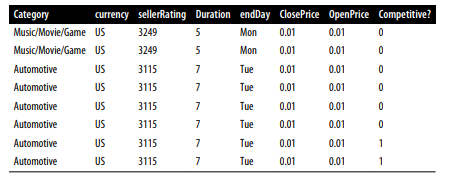



Data Frame and Indexes
  Traditonal database tables have one or more columns designated as an index, essentially a row number. Ths can vasty improve the efficiency of certain databsase queries.

Key Ideas
  - The basic data structure n data science is a rectangular matrix in wich rows are records and columns are variables.
  - Terminology can be confusing; there are a variety of synonyms arising from the different disciplines that contribute to data science.

In [ ]:
pip install wquantiles

In [ ]:
!pip install wquantiles

%matplotlib inline

from pathlib import Path

import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles

import seaborn as sns
import matplotlib.pylab as plt

In [ ]:
# Table 1-2
state = pd.read_csv('state.csv')
print(state.head(8))

FileNotFoundError: [Errno 2] No such file or directory: 'state.csv'

Shows the first few rows in the data set contaniing population and murder rates for each US state


## Mean

The most basic estimate of location is the mean, or average value. The mean is the sum of all values divided by the number of values. Consider the following set of numbers.

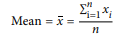

A variaton of the mean is a trimmed mean, which calculate by dropping a fixed number of sorted values at each end and then taking an average of the remaining values.

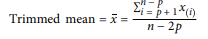

Another type of mean is a weithed mean, which you calculate byu multiiplying each data value xi by a user specfied weight wi and dividing their sum by the sum of the weight.

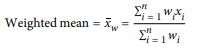

## Median and Robust Estimates

The median is the middle number on a sorted list of the data. If there is an even number of data values, the middle value is one that is not actually in the data set, but rather the average of the two values that divide the sorted data into upper and lower halves.

Outliers
  the median is referred to as a robust estimate of location since it is not influenced by outliers that could skew the results. An outlier is any value that is very diistant from the other values in a data set.
  The Median is not the only robust estimate of location. In fact, a trimmed mean is widely used  to avoid the influence of ouliers.

## Estimates of Variability

Location is just one dimension in summarizing a feature. A second dimension, variability, aslo referred to as dispersion, measures whether the data values are tightly clustered or spread out.

Key Temrs of Variability Metrics
  Deviations, The difference between the observed values and the estimate of location.

  Variance, the sum of squared deviations from the mean divided by n - 1 where n is the number of data values.

  Standard Deviation, the square root of the variance.

  Mean Absolute Deviation, The mean of the absolute values of the deviations from the mean.

  Median Absolute Deviation from the Median, the median of the absolute values of the deviations from the median.

  Range, the difference between the largest and the smallest value in a data set.

  Order statistics, metrics based on the data values sorted from smallest to biggest.

  Percentile, the value such that P percent of the values take on this value or less and (100-P) percent take on this value or more.

  Interquartile range, the difference between the 75th percentile and the 25th percentile.

## Standard Deviation and Related Estimates.

The most widely used estimates of variation are based on the differences, or deviations, between the estimate of location and the observed data.


One way to measure variability is to estimate a typical value for these deviations. Averaging the deviations themselves would not tell us much—the negative deviations offset the positive ones.

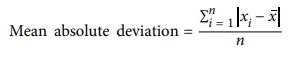


The best-known estimates of variability are the variance and the standard deviation, which are based on squared deviations. The variance is an average of the squared deviations, and the standard deviation is the square root of the variance.

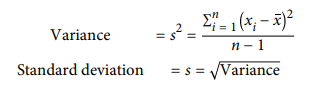

## Estimates Based on Percentiles

A different apporach to estimating dispersion is based on looking at the spread of the sorted data. Statistics based on sorted (ranked) data are referred to as order statistics. The most basic measure is the range: the difference between the largest and smallest numbers. The minimum and maximum values themselves are useful to know and are helpful in identifying otliers, but the range is extremely sensitive to outliers and not very useful as a general measure of dispersion in the data.

For very large data sets, calculating exact percentiles can be computationally very expensive since it requires sorting all the data values.


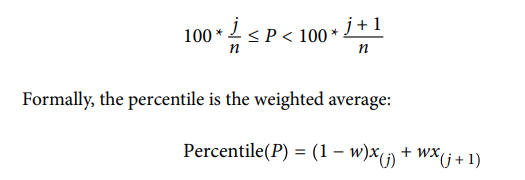

## Example: Variability Estimates of State Population

In [3]:
print(state['Population'].std())
print(state['Population'].quantile(0.75) - state['Population'].quantile(0.25))
print(robust.scale.mad(state['Population']))

NameError: name 'state' is not defined

The pandas data frame provides methods for calculating standard deviation and quantiles. Using the quantiles,we can easily detemine the IQR. For the Robust MAD, we use the function robust.scale.mad from the statsmodels package

In [2]:
state['Population'].std()
state['Population'].quantile(0.75) - state['Population'].quantile(0.25)
robust.scale.mad(state['Population'])

NameError: name 'state' is not defined

## Exploring the Data Distribution

Each of the estimates we've covered sums up the data in a single number to describe the location or variability of the data.

Key Terms for Exploring the Distribution
  
Boxplot, a plot introduced by Tukey as a quick way to visualiize the distribution of data.

Frequency Table,  a tally of the count of numeric data values that fall into a set of intervals.

Histogram, a plot of the frequency table with the bins on the x-axis and the count on the y-axis.

Density plot, a smoothed version of the histogram, often based on a kernel density estimate.

## Percentiles and Boxplots

In "Estimates Based on Percentiles", we explored how percentiles can be used to measure the spread of the data. Percentiles are also valuable for summarizing the entire distriibution.

In [4]:
quantile(state[['Murder.Rate']], p=c(.05, .25, .5, .75, .95))
5% 25% 50% 75% 95%
1.600 2.425 4.000 5.550 6.510
state['Murder.Rate'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

SyntaxError: invalid syntax (3710293698.py, line 2)

Boxplots, Introduced by TUkey, are based on percentiles and give a quick way to visualize the distribution of data.

In [ ]:
boxplot(state[['Population']]/1000000, ylab='Population (millions)')
ax = (state['Population']/1_000_000).plot.box()
ax.set_ylabel('Population (millions)')

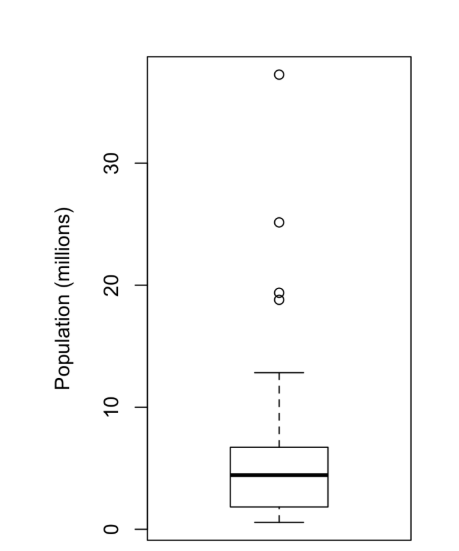

## Frequency Tables and Histograms

In [ ]:
breaks <- seq(from=min(state[['Population']]),
to=max(state[['Population']]), length=11)
pop_freq <- cut(state[['Population']], breaks=breaks,
right=TRUE, include.lowest=TRUE)
table(pop_freq)

In [ ]:
binnedPopulation = pd.cut(state['Population'], 10)
binnedPopulation.value_counts()

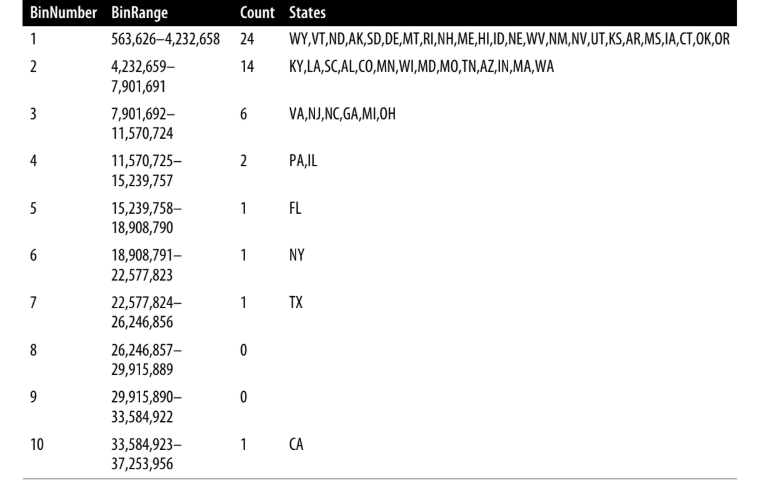

The least populous state is Wyoming, with 563,626 people, and the most populous is California, with 37,253,956 people.

A histogram is a way to visualize a frequency table, with bins on the x-axis and the
data count on the y-axis.

In [ ]:
hist(state[['Population']], breaks=breaks)
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Population (millions)')

pandas supports histograms for data frames with the DataFrame.plot.hist method.
Use the keyword argument bins to define the number of bins.

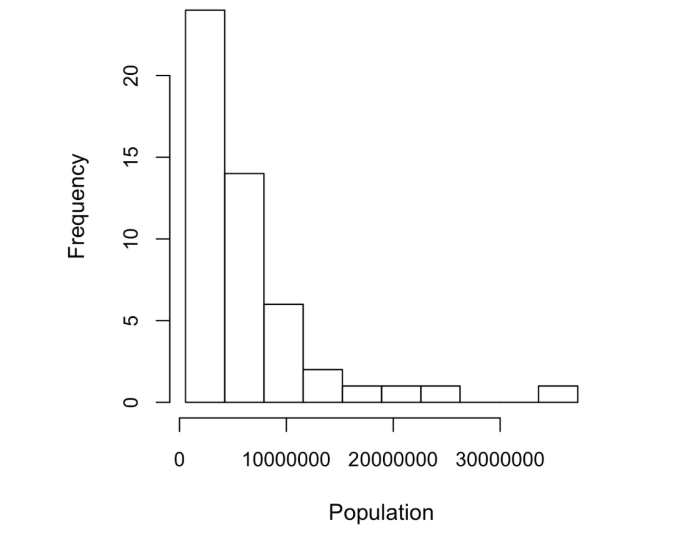

## Density Plots and Estimates

Related to the histogram is a density plot, which shows the distribution of data values as a continuous line. A density plot can be thought of as a smoothed histogram, although it is typically computed directly from the data through a kernel density extimate.

In [5]:
hist(state[['Murder.Rate']], freq=FALSE)
lines(density(state[['Murder.Rate']]), lwd=3, col='blue')
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0,12], bins=range(1,12))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder Rate (per 100,000)')

NameError: name 'hist' is not defined

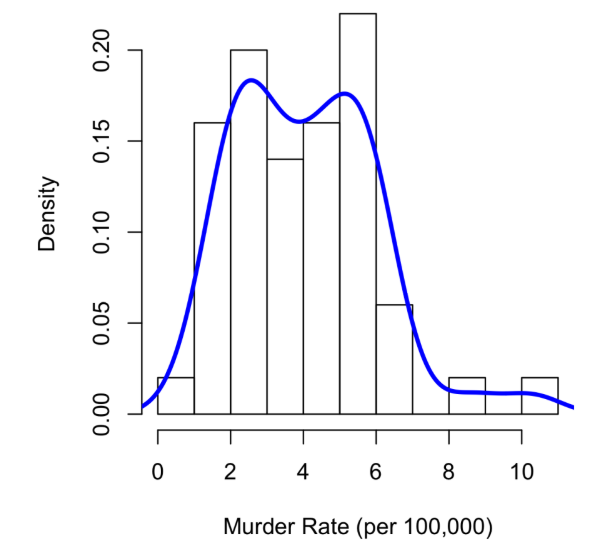

## Esploring Data and Categorical Data

Key Terms for Exploring Categorical Data

Mode, the most commonly occuring category or value in a data set.

Expecter Value, when the categories can be associated with a numeric value, this gives an average value based on a category's probably of occurrence.

Bar Charts, the frequency or proportion for each category plotted as bars.

Pie charts, the frequency or proportion for each category plotted as wedges in a pie.

In [ ]:
barplot(as.matrix(dfw) / 6, cex.axis=0.8, cex.names=0.7,
xlab='Cause of delay', ylab='Count')
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Cause of delay')
ax.set_ylabel('Count')

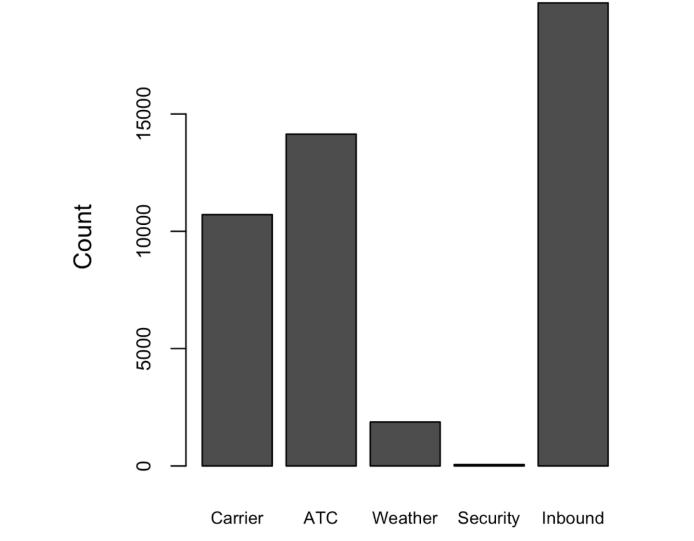